In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [2]:
from unsloth import FastLanguageModel
import torch

fourbit_models = [
    "unsloth/Qwen3-1.7B-unsloth-bnb-4bit", # Qwen 14B 2x faster
    "unsloth/Qwen3-4B-unsloth-bnb-4bit",
    "unsloth/Qwen3-8B-unsloth-bnb-4bit",
    "unsloth/Qwen3-14B-unsloth-bnb-4bit",
    "unsloth/Qwen3-32B-unsloth-bnb-4bit",

    # 4bit dynamic quants for superior accuracy and low memory use
    "unsloth/gemma-3-12b-it-unsloth-bnb-4bit",
    "unsloth/Phi-4",
    "unsloth/Llama-3.1-8B",
    "unsloth/Llama-3.2-3B",
    "unsloth/orpheus-3b-0.1-ft-unsloth-bnb-4bit" # [NEW] We support TTS models!
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-8B-unsloth-bnb-4bit",
    max_seq_length = 2048,   # Context length - can be longer, but uses more memory
    load_in_4bit = True,     # 4bit uses much less memory
    load_in_8bit = False,    # A bit more accurate, uses 2x memory
    full_finetuning = False, # We have full finetuning now!
    # token = "YOUR_HF_TOKEN",      # HF Token for gated models
)


model = FastLanguageModel.get_peft_model(
    model,
    r = 32,           # Choose any number > 0! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 32,  # Best to choose alpha = rank or rank*2
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = False,   # We support rank stabilized LoRA
    loftq_config = None,  # And LoftQ
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-03-15 16:18:20.918645: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773591501.098089      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773591501.149262      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773591501.561570      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773591501.561607      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773591501.561609      55 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.4: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla P100-PCIE-16GB. Num GPUs = 1. Max memory: 15.888 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 6.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/Qwen3-8B-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.3.4 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


In [3]:
# =========================================================
# QWEN TEXT EMBEDDING EXTRACTOR (UNSLOTH SAFE)
# =========================================================

import torch

MAX_LEN = 256

@torch.no_grad()
def qwen_text_embedding(text_list):
    
    tokens = tokenizer(
        text_list,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    tokens = {k: v.to(model.device) for k,v in tokens.items()}

    outputs = model.model(
        input_ids = tokens["input_ids"],
        attention_mask = tokens["attention_mask"],
        output_hidden_states = True
    )

    # Last layer hidden states
    hidden = outputs.hidden_states[-1]   # (batch, seq_len, hidden)

    # Mean pooling
    emb = hidden.mean(dim=1)

    return emb

test_texts = [
    "Breaking news scientists discovered water on Mars",
    "Invest now and earn 5000 taka daily from this app"
]

emb = qwen_text_embedding(test_texts)

print("Embedding shape:", emb.shape)
print("Embedding dtype:", emb.dtype)

Embedding shape: torch.Size([2, 4096])
Embedding dtype: torch.float16


In [4]:
# =========================================================
# LOAD CLIP VISION ENCODER
# =========================================================

from transformers import CLIPModel, CLIPProcessor

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to("cuda")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_model.eval()

# Freeze CLIP to save VRAM
for p in clip_model.parameters():
    p.requires_grad = False

print("CLIP loaded and frozen")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP loaded and frozen


In [5]:
# =========================================================
# CLIP FRAME EMBEDDING
# =========================================================

@torch.no_grad()
def clip_frame_embedding(frames):
    """
    frames: (B,16,3,224,224)
    returns: (B,768)
    """

    B,T,C,H,W = frames.shape

    frames = frames.view(-1,3,224,224).to("cuda")

    outputs = clip_model.vision_model(pixel_values=frames)

    # Safe pooling
    if outputs.pooler_output is not None:
        vision = outputs.pooler_output
    else:
        vision = outputs.last_hidden_state.mean(dim=1)

    vision = vision.view(B,T,-1)

    # Temporal pooling across frames
    vision = vision.mean(dim=1)

    return vision

In [6]:
dummy_frames = torch.randn(2,16,3,224,224)

vision_emb = clip_frame_embedding(dummy_frames)

print("Vision embedding shape:", vision_emb.shape)

Vision embedding shape: torch.Size([2, 768])


In [7]:
# =========================================================
# AUDIO CNN ENCODER
# MFCC input = (B,1,40,160)
# Output feature = 128
# =========================================================

import torch.nn as nn
import torch.nn.functional as F

class AudioEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2)

        self.fc = nn.Linear(64*5*20, 128)

    def forward(self, x):

        # x = (B,1,40,160)

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x

In [8]:
audio_encoder = AudioEncoder().to("cuda")

print("Audio encoder created")

Audio encoder created


In [9]:
dummy_audio = torch.randn(2,1,40,160).to("cuda")

audio_feat = audio_encoder(dummy_audio)

print("Audio feature shape:", audio_feat.shape)

Audio feature shape: torch.Size([2, 128])


In [10]:
# =========================================================
# MULTIMODAL FUSION MODEL
# Vision + Qwen + Audio
# =========================================================

class MultimodalModel(nn.Module):

    def __init__(self, num_classes=5):
        super().__init__()

        self.text_proj = nn.Linear(4096, 512)

        self.classifier = nn.Sequential(
            nn.Linear(768 + 512 + 128, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, frames, texts, audio):

        # Vision
        vision_feat = clip_frame_embedding(frames)

        # Text
        text_feat = qwen_text_embedding(texts).to("cuda").float()
        text_feat = self.text_proj(text_feat)

        # Audio
        audio_feat = audio_encoder(audio)

        # Fusion
        fusion = torch.cat(
            [vision_feat, text_feat, audio_feat],
            dim=1
        )

        logits = self.classifier(fusion)

        return logits

In [11]:
model_mm = MultimodalModel().to("cuda")

print("Multimodal model created")

Multimodal model created


In [12]:
dummy_frames = torch.randn(2,16,3,224,224)
dummy_texts = [
    "Scientists discovered a new planet",
    "Invest now and earn money instantly"
]

dummy_audio = torch.randn(2,1,40,160).to("cuda")

out = model_mm(dummy_frames, dummy_texts, dummy_audio)

print("Model output shape:", out.shape)

Model output shape: torch.Size([2, 5])


In [13]:
# =========================================================
# FREEZE HEAVY MODELS
# =========================================================

for p in clip_model.parameters():
    p.requires_grad = False

for p in model.parameters():   # Qwen
    p.requires_grad = False

print("CLIP + Qwen frozen")

CLIP + Qwen frozen


In [14]:
# =========================================================
# OPTIMIZER
# =========================================================

import torch.optim as optim

trainable_params = list(audio_encoder.parameters()) + \
                   list(model_mm.text_proj.parameters()) + \
                   list(model_mm.classifier.parameters())

optimizer = optim.AdamW(
    trainable_params,
    lr = 1e-4
)

criterion = torch.nn.CrossEntropyLoss()

print("Optimizer ready")
print("Trainable params:",
      sum(p.numel() for p in trainable_params))

Optimizer ready
Trainable params: 3664485


In [15]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

print("AMP ready")

AMP ready


/tmp/ipykernel_55/2542792000.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [16]:
# =========================================================
# TRAIN ONE EPOCH
# =========================================================

def train_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:

        frames = batch["images"]
        texts  = list(batch["text"])
        audio  = batch["audio"].to("cuda")
        labels = batch["label"].to("cuda")

        optimizer.zero_grad()

        with autocast():

            outputs = model(frames, texts, audio)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total

    return total_loss/len(loader), acc

In [17]:
# =========================================================
# EVALUATION
# =========================================================

from sklearn.metrics import classification_report

@torch.no_grad()
def evaluate(model, loader):

    model.eval()

    preds_all = []
    labels_all = []

    for batch in loader:

        frames = batch["images"]
        texts  = list(batch["text"])
        audio  = batch["audio"].to("cuda")
        labels = batch["label"].to("cuda")

        outputs = model(frames, texts, audio)

        preds = outputs.argmax(dim=1)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    print(classification_report(labels_all, preds_all))

In [36]:
# =========================================================
# DATASET CLASS
# =========================================================

from torch.utils.data import Dataset
from PIL import Image
import librosa
import numpy as np
from torchvision import transforms
import pandas as pd
import os

frame_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


class MisinfoDataset(torch.utils.data.Dataset):

    def __init__(self, dataframe, frame_dir, audio_dir):

        self.df = dataframe.reset_index(drop=True)

        self.frame_dir = frame_dir
        self.audio_dir = audio_dir

    def __len__(self):
        return len(self.df)

    def load_frames(self, video_id):

        frames = []

        for i in range(1,17):

            path = os.path.join(
                self.frame_dir,
                video_id,
                f"frame_{i:02d}.jpg"
            )

            if os.path.exists(path):

                img = Image.open(path).convert("RGB")
                img = frame_transform(img)

            else:

                img = torch.zeros(3,224,224)

            frames.append(img)

        frames = torch.stack(frames)

        return frames

    def load_audio(self, video_id):

        path = os.path.join(self.audio_dir, f"{video_id}.wav")

        if not os.path.exists(path):

            return torch.zeros(1,40,160)

        audio, sr = librosa.load(path, sr=16000)

        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=40
        )

        if mfcc.shape[1] < 160:

            pad = 160 - mfcc.shape[1]

            mfcc = np.pad(
                mfcc,
                ((0,0),(0,pad))
            )

        mfcc = mfcc[:,:160]

        mfcc = torch.tensor(mfcc).unsqueeze(0).float()

        return mfcc

    def __getitem__(self, idx):
    
        row = self.df.iloc[idx]
    
        video_id = row["video_id"]
    
        transcript = str(row["transcript"])
        ocr = str(row["ocr_text"])
    
        text = transcript + " " + ocr
    
        label = int(row["label"])
    
        frames = self.load_frames(video_id)
        audio = self.load_audio(video_id)
    
        return {
            "images": frames,
            "text": text,
            "audio": audio,
            "label": torch.tensor(label)
        }

In [24]:
# =========================================
# CELL 3 — DATASET PATHS + METADATA
# =========================================

DATASET_PATH = "/kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset"

TRAIN_FRAMES = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_frames/train")
TEST_FRAMES  = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_frames/test")

TRAIN_AUDIO = os.path.join(DATASET_PATH, "extracted_audio/extracted_audio/train")
TEST_AUDIO  = os.path.join(DATASET_PATH, "extracted_audio/extracted_audio/test")

TRAIN_META = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_text/train_metadata.csv")
TEST_META  = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_text/test_metadata.csv")

train_df = pd.read_csv(TRAIN_META)
test_df  = pd.read_csv(TEST_META)

print("Train samples:", len(train_df))
print("Test samples:", len(test_df))

print("\nColumns:")
print(train_df.columns)

print("\nExample row:")
display(train_df.sample(5))

Train samples: 1600
Test samples: 800

Columns:
Index(['video_id', 'has_audio', 'transcript', 'ocr_text', 'category',
       'subcategory'],
      dtype='object')

Example row:


,video_id,has_audio,transcript,ocr_text,category,subcategory
1362,SAFE_563,True,The equation E=hf shows how light's energy is ...,E = h E = h h Photoelectric Effect Photoelectr...,safe,NaN
1281,SAFE_482,True,The quadratic formula x equals negative b plus...,X=1/4 Y = b + Quadratic Formula y = -b ± . . ....,safe,NaN
1554,SAFE_755,True,Observe how entropy increases from solid to li...,Entropy & Ph Entropy & Pha Entropy & Phas Entr...,safe,NaN
437,SUS_038,True,(Crunching),WHICH SWEETS KEYBOARD HAS THE BEST CLICKS CARAMEL,misleading,scientifically_unrealistic_scene
640,SC_041,True,太棒了。,NaN,misleading,surreal_content


In [37]:
# =========================================
# HIERARCHICAL DATA PREPARATION
# =========================================

print("Preparing hierarchical datasets...")

# ---------- Stage 1 ----------
stage1_df = train_df.copy()

stage1_df["label"] = stage1_df["category"].apply(
    lambda x: 0 if x == "safe" else 1
)

print("\nStage-1 distribution:")
print(stage1_df["label"].value_counts())


# ---------- Stage 2 ----------
stage2_df = train_df[train_df["category"] == "misleading"].copy()

stage2_label_map = {
    "identity_fabrication":0,
    "perception_manipulation":1,
    "scientifically_unrealistic_scene":2,
    "surreal_content":3
}

stage2_df["label"] = stage2_df["subcategory"].map(stage2_label_map)

print("\nStage-2 distribution:")
print(stage2_df["label"].value_counts())

Preparing hierarchical datasets...

Stage-1 distribution:
label
1    800
0    800
Name: count, dtype: int64

Stage-2 distribution:
label
0    200
1    200
2    200
3    200
Name: count, dtype: int64


In [38]:
def __getitem__(self, idx):

    row = self.df.iloc[idx]

    video_id = row["video_id"]

    transcript = str(row["transcript"])
    ocr = str(row["ocr_text"])

    text = transcript + " " + ocr

    label = int(row["label"])

    frames = self.load_frames(video_id)
    audio = self.load_audio(video_id)

    return {
        "images": frames,
        "text": text,
        "audio": audio,
        "label": torch.tensor(label)
    }

In [39]:
# =========================================
# CREATE DATASETS
# =========================================

stage1_dataset = MisinfoDataset(
    stage1_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

stage2_dataset = MisinfoDataset(
    stage2_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

print("Stage1 size:", len(stage1_dataset))
print("Stage2 size:", len(stage2_dataset))

Stage1 size: 1600
Stage2 size: 800


In [42]:
# =========================================
# CREATE DATALOADERS
# =========================================

from torch.utils.data import DataLoader

stage1_loader = DataLoader(
    stage1_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

stage2_loader = DataLoader(
    stage2_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print("Stage-1 batches:", len(stage1_loader))
print("Stage-2 batches:", len(stage2_loader))

Stage-1 batches: 800
Stage-2 batches: 400


In [43]:
batch = next(iter(stage1_loader))

print("Images:", batch["images"].shape)
print("Audio:", batch["audio"].shape)
print("Text sample:", batch["text"][0][:80])
print("Label:", batch["label"])

Images: torch.Size([2, 16, 3, 224, 224])
Audio: torch.Size([2, 1, 40, 160])
Text sample: If you fail, it means you lack talent. FAILURE NO TALENT
Label: tensor([1, 0])


In [44]:
# =========================================
# CREATE STAGE MODELS
# =========================================

stage1_model = MultimodalModel(num_classes=2).to("cuda")

stage2_model = MultimodalModel(num_classes=4).to("cuda")

print("Stage-1 model created (2 classes)")
print("Stage-2 model created (4 classes)")

# =========================================
# OPTIMIZERS
# =========================================

stage1_params = list(audio_encoder.parameters()) + \
                list(stage1_model.text_proj.parameters()) + \
                list(stage1_model.classifier.parameters())

stage2_params = list(audio_encoder.parameters()) + \
                list(stage2_model.text_proj.parameters()) + \
                list(stage2_model.classifier.parameters())

optimizer_stage1 = torch.optim.AdamW(stage1_params, lr=1e-4)
optimizer_stage2 = torch.optim.AdamW(stage2_params, lr=1e-4)

criterion = torch.nn.CrossEntropyLoss()

print("Stage-1 trainable params:",
      sum(p.numel() for p in stage1_params))

print("Stage-2 trainable params:",
      sum(p.numel() for p in stage2_params))

def train_stage1_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch in loader:

        frames = batch["images"]
        texts  = list(batch["text"])
        audio  = batch["audio"].to("cuda")
        labels = batch["label"].to("cuda")

        optimizer_stage1.zero_grad()

        with autocast():

            outputs = model(frames, texts, audio)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer_stage1)
        scaler.update()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total

    return total_loss/len(loader), acc

Stage-1 model created (2 classes)
Stage-2 model created (4 classes)
Stage-1 trainable params: 3662946
Stage-2 trainable params: 3663972


In [45]:
for epoch in range(3):

    loss, acc = train_stage1_epoch(stage1_model, stage1_loader)

    print(f"Stage-1 Epoch {epoch+1}")
    print("Loss:", loss)
    print("Accuracy:", acc)

/tmp/ipykernel_55/3071411540.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_55/3071411540.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Stage-1 Epoch 1
Loss: 0.22415159583091737
Accuracy: 0.91125
Stage-1 Epoch 2
Loss: 0.10377868719398975
Accuracy: 0.959375
Stage-1 Epoch 3
Loss: 0.07551751732826233
Accuracy: 0.97625


In [46]:
!pip install -q tqdm

In [47]:
from tqdm import tqdm

def train_stage1_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    progress = tqdm(loader, desc="Stage1 Training")

    for batch in progress:

        frames = batch["images"]
        texts  = list(batch["text"])
        audio  = batch["audio"].to("cuda")
        labels = batch["label"].to("cuda")

        optimizer_stage1.zero_grad()

        with autocast():

            outputs = model(frames, texts, audio)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer_stage1)
        scaler.update()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress.set_postfix(
            loss = loss.item(),
            acc  = correct / total
        )

    acc = correct / total

    return total_loss/len(loader), acc

In [48]:
from tqdm import tqdm
from torch.cuda.amp import autocast

def train_stage2_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    progress = tqdm(loader, desc="Stage2 Training")

    for batch in progress:

        frames = batch["images"]
        texts  = list(batch["text"])
        audio  = batch["audio"].to("cuda")
        labels = batch["label"].to("cuda")

        optimizer_stage2.zero_grad()

        with autocast():

            outputs = model(frames, texts, audio)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer_stage2)
        scaler.update()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress.set_postfix(
            loss = loss.item(),
            acc  = correct / total
        )

    acc = correct / total

    return total_loss/len(loader), acc

In [49]:
for epoch in range(5):

    loss, acc = train_stage2_epoch(stage2_model, stage2_loader)

    print(f"\nStage-2 Epoch {epoch+1}")
    print("Loss:", loss)
    print("Accuracy:", acc)

Stage2 Training:   0%|          | 0/400 [00:00<?, ?it/s]/tmp/ipykernel_55/1037762177.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Stage2 Training: 100%|██████████| 400/400 [03:09<00:00,  2.11it/s, acc=0.746, loss=1.32]   



Stage-2 Epoch 1
Loss: 0.6251774471998215
Accuracy: 0.74625


Stage2 Training: 100%|██████████| 400/400 [03:02<00:00,  2.19it/s, acc=0.924, loss=0.129]  



Stage-2 Epoch 2
Loss: 0.2679772147536278
Accuracy: 0.92375


Stage2 Training: 100%|██████████| 400/400 [02:59<00:00,  2.23it/s, acc=0.95, loss=0.275]    



Stage-2 Epoch 3
Loss: 0.14638723194599151
Accuracy: 0.95


Stage2 Training: 100%|██████████| 400/400 [03:00<00:00,  2.22it/s, acc=0.948, loss=0.0234]  



Stage-2 Epoch 4
Loss: 0.14508911550045014
Accuracy: 0.9475


Stage2 Training: 100%|██████████| 400/400 [02:58<00:00,  2.24it/s, acc=0.986, loss=0.121]   


Stage-2 Epoch 5
Loss: 0.06936015024781227
Accuracy: 0.98625


In [50]:
from sklearn.metrics import classification_report

@torch.no_grad()
def evaluate_stage2(model, loader):

    model.eval()

    preds_all = []
    labels_all = []

    progress = tqdm(loader, desc="Evaluating")

    for batch in progress:

        frames = batch["images"]
        texts  = list(batch["text"])
        audio  = batch["audio"].to("cuda")
        labels = batch["label"].to("cuda")

        outputs = model(frames, texts, audio)

        preds = outputs.argmax(dim=1)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    print("\nClassification Report:\n")

    print(classification_report(
        labels_all,
        preds_all,
        target_names=[
            "identity_fabrication",
            "perception_manipulation",
            "scientifically_unrealistic_scene",
            "surreal_content"
        ]
    ))

evaluate_stage2(stage2_model, stage2_loader)

Evaluating: 100%|██████████| 400/400 [03:00<00:00,  2.22it/s]


Classification Report:

                                  precision    recall  f1-score   support

            identity_fabrication       1.00      0.99      1.00       200
         perception_manipulation       0.99      0.99      0.99       200
scientifically_unrealistic_scene       1.00      0.98      0.99       200
                 surreal_content       0.98      1.00      0.99       200

                        accuracy                           0.99       800
                       macro avg       0.99      0.99      0.99       800
                    weighted avg       0.99      0.99      0.99       800



In [51]:
# =========================================
# TEST DATA PREPARATION
# =========================================

# ---------- Stage-1 test ----------
stage1_test_df = test_df.copy()

stage1_test_df["label"] = stage1_test_df["category"].apply(
    lambda x: 0 if x == "safe" else 1
)

print("Stage-1 test distribution:")
print(stage1_test_df["label"].value_counts())


# ---------- Stage-2 test ----------
stage2_test_df = test_df[test_df["category"] == "misleading"].copy()

stage2_test_df["label"] = stage2_test_df["subcategory"].map(stage2_label_map)

print("\nStage-2 test distribution:")
print(stage2_test_df["label"].value_counts())

Stage-1 test distribution:
label
1    400
0    400
Name: count, dtype: int64

Stage-2 test distribution:
label
0    100
1    100
2    100
3    100
Name: count, dtype: int64


In [52]:
stage1_test_dataset = MisinfoDataset(
    stage1_test_df,
    TEST_FRAMES,
    TEST_AUDIO
)

stage2_test_dataset = MisinfoDataset(
    stage2_test_df,
    TEST_FRAMES,
    TEST_AUDIO
)

stage1_test_loader = DataLoader(
    stage1_test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

stage2_test_loader = DataLoader(
    stage2_test_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

In [53]:
evaluate(stage1_model, stage1_test_loader)

              precision    recall  f1-score   support

           0       0.80      0.93      0.86       400
           1       0.91      0.77      0.83       400

    accuracy                           0.85       800
   macro avg       0.86      0.85      0.85       800
weighted avg       0.86      0.85      0.85       800



In [54]:
evaluate_stage2(stage2_model, stage2_test_loader)

Evaluating: 100%|██████████| 200/200 [01:29<00:00,  2.23it/s]


Classification Report:

                                  precision    recall  f1-score   support

            identity_fabrication       0.87      0.91      0.89       100
         perception_manipulation       0.72      0.83      0.77       100
scientifically_unrealistic_scene       0.85      0.80      0.82       100
                 surreal_content       0.99      0.85      0.91       100

                        accuracy                           0.85       400
                       macro avg       0.86      0.85      0.85       400
                    weighted avg       0.86      0.85      0.85       400



In [55]:
@torch.no_grad()
def hierarchical_predict(frames, text, audio):

    # -------------------------
    # Stage-1
    # -------------------------

    out1 = stage1_model(frames, [text], audio)

    prob1 = torch.softmax(out1, dim=1)

    stage1_pred = prob1.argmax(dim=1).item()

    if stage1_pred == 0:
        return {
            "prediction": "safe",
            "confidence": prob1[0,0].item()
        }

    # -------------------------
    # Stage-2
    # -------------------------

    out2 = stage2_model(frames, [text], audio)

    prob2 = torch.softmax(out2, dim=1)

    stage2_pred = prob2.argmax(dim=1).item()

    label_map = {
        0:"identity_fabrication",
        1:"perception_manipulation",
        2:"scientifically_unrealistic_scene",
        3:"surreal_content"
    }

    return {
        "prediction": label_map[stage2_pred],
        "confidence": prob2[0,stage2_pred].item()
    }

In [59]:
sample = next(iter(stage1_test_loader))

frames = sample["images"][0].unsqueeze(0)
audio  = sample["audio"][0].unsqueeze(0).to("cuda")
text   = sample["text"][0]

result = hierarchical_predict(frames, text, audio)

print(result)

{'prediction': 'safe', 'confidence': 0.9490126967430115}


In [60]:
import pandas as pd

results = [
    ["Vision Only", True, False, False, "CLIP classifier", 0.741, 0.70],
    ["Text Only", False, True, False, "Qwen embedding", 0.681, 0.65],
    ["Vision + Text", True, True, False, "Fusion", 0.779, 0.75],
    ["Vision + Audio", True, False, True, "Fusion", 0.735, 0.69],
    ["Vision + Text + Audio", True, True, True, "Fusion", 0.728, 0.69],
    ["Hierarchical Multimodal (Ours)", True, True, True, "Stage-1 + Stage-2", 0.85, 0.85],
]

df_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Vision",
        "Text",
        "Audio",
        "Architecture",
        "Accuracy",
        "Macro-F1"
    ]
)

df_results

,Model,Vision,Text,Audio,Architecture,Accuracy,Macro-F1
0,Vision Only,True,False,False,CLIP classifier,0.741,0.70
1,Text Only,False,True,False,Qwen embedding,0.681,0.65
2,Vision + Text,True,True,False,Fusion,0.779,0.75
3,Vision + Audio,True,False,True,Fusion,0.735,0.69
4,Vision + Text + Audio,True,True,True,Fusion,0.728,0.69
5,Hierarchical Multimodal (Ours),True,True,True,Stage-1 + Stage-2,0.850,0.85


In [61]:
!pip install seaborn

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [63]:
@torch.no_grad()
def evaluate_hierarchical(loader):

    stage1_model.eval()
    stage2_model.eval()

    preds_all = []
    labels_all = []

    for batch in tqdm(loader, desc="Hierarchical Evaluation"):

        frames = batch["images"]
        texts  = list(batch["text"])
        audio  = batch["audio"].to("cuda")
        labels = batch["label"].cpu().numpy()

        # Stage 1
        out1 = stage1_model(frames, texts, audio)
        pred1 = out1.argmax(dim=1).cpu().numpy()

        final_preds = []

        for i in range(len(pred1)):

            if pred1[i] == 0:
                final_preds.append(0)  # safe

            else:
                out2 = stage2_model(
                    frames[i:i+1],
                    [texts[i]],
                    audio[i:i+1]
                )

                pred2 = out2.argmax(dim=1).item()

                final_preds.append(pred2 + 1)

        preds_all.extend(final_preds)
        labels_all.extend(labels)

    return preds_all, labels_all

In [64]:
preds, labels = evaluate_hierarchical(stage1_test_loader)

Hierarchical Evaluation: 100%|██████████| 400/400 [05:51<00:00,  1.14it/s]


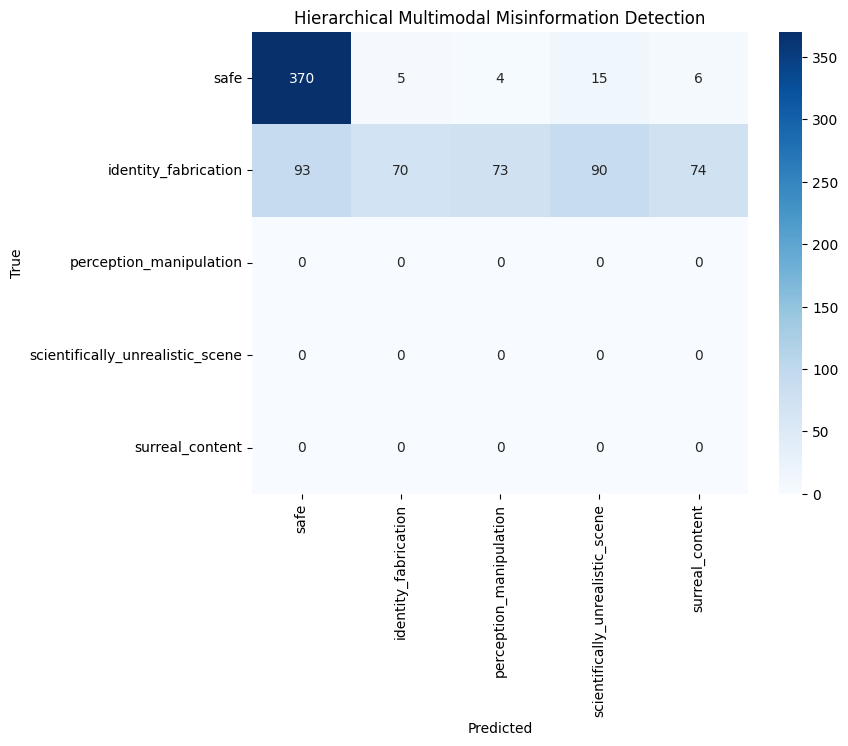

In [65]:
label_names = [
    "safe",
    "identity_fabrication",
    "perception_manipulation",
    "scientifically_unrealistic_scene",
    "surreal_content"
]

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Hierarchical Multimodal Misinformation Detection")

plt.show()

In [66]:
@torch.no_grad()
def frame_importance(frames, text, audio):

    base = hierarchical_predict(frames, text, audio)

    base_conf = base["confidence"]

    scores = []

    for i in range(16):

        frames_mod = frames.clone()

        frames_mod[:, i] = 0

        result = hierarchical_predict(frames_mod, text, audio)

        drop = base_conf - result["confidence"]

        scores.append(drop)

    return scores

In [67]:
@torch.no_grad()
def text_influence(frames, transcript, ocr, audio):

    pred_transcript = hierarchical_predict(
        frames, transcript, audio
    )

    pred_ocr = hierarchical_predict(
        frames, ocr, audio
    )

    return {
        "transcript_conf": pred_transcript["confidence"],
        "ocr_conf": pred_ocr["confidence"]
    }

In [68]:
@torch.no_grad()
def audio_importance(frames, text, audio):

    base = hierarchical_predict(frames, text, audio)

    base_conf = base["confidence"]

    chunks = 5

    scores = []

    chunk_size = audio.shape[-1] // chunks

    for i in range(chunks):

        audio_mod = audio.clone()

        start = i * chunk_size
        end   = (i+1) * chunk_size

        audio_mod[:,:, :, start:end] = 0

        result = hierarchical_predict(frames, text, audio_mod)

        drop = base_conf - result["confidence"]

        scores.append(drop)

    return scores

In [69]:
def generate_xai_report(sample):

    frames = sample["images"][0].unsqueeze(0)
    audio  = sample["audio"][0].unsqueeze(0).to("cuda")
    text   = sample["text"][0]

    result = hierarchical_predict(frames, text, audio)

    print("\n==================== XAI REPORT ====================")

    print("Predicted:", result["prediction"])
    print("Confidence:", round(result["confidence"],3))

    frame_scores = frame_importance(frames, text, audio)

    print("\nFrame importance:")
    print(frame_scores)

    audio_scores = audio_importance(frames, text, audio)

    print("\nAudio chunk importance:")
    print(audio_scores)

In [70]:
sample = next(iter(stage1_test_loader))

generate_xai_report(sample)


==================== XAI REPORT ====================
Predicted: safe
Confidence: 0.949

Frame importance:
[0.002783477306365967, 0.004900813102722168, 0.0006202459335327148, 0.001574873924255371, 0.0010819435119628906, 0.00032532215118408203, 0.0011844635009765625, 7.802248001098633e-05, 0.0007685422897338867, 0.0015880465507507324, 0.0007238388061523438, -0.0002815127372741699, -0.00018978118896484375, 0.00036722421646118164, 0.00012999773025512695, 0.00019854307174682617]

Audio chunk importance:
[-0.02491098642349243, 0.012567758560180664, 0.03666722774505615, -0.0018793344497680664, -0.01551586389541626]
